In [18]:
import pandas as pd

Development = pd.read_csv("../Dataset/HDI.csv")
Development.head()

,Country,HDI,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita,Internet users
0,Afghanistan,0.798,55.4,6.3,56017,64.2
1,Albania,0.816,64.8,5.2,22680,95.5
2,Algeria,0.881,71.4,9.7,72165,27.8
3,Andorra,0.917,83.9,11.0,59257,21.8
4,Angola,0.854,84.5,10.2,35117,21.2


In [19]:
Development.shape

(191, 6)

In [20]:
Development.columns

Index(['Country', 'HDI', 'Life expectancy', 'Mean years of schooling',
       'Gross national income (GNI) per capita', 'Internet users'],
      dtype='object')

In [21]:
Development.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 191 non-null    object 
 1   HDI                                     191 non-null    float64
 2   Life expectancy                         191 non-null    float64
 3   Mean years of schooling                 191 non-null    float64
 4   Gross national income (GNI) per capita  191 non-null    int64  
 5   Internet users                          191 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.1+ KB


In [22]:
Development.isnull().sum()

Country                                   0
HDI                                       0
Life expectancy                           0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
Internet users                            0
dtype: int64

In [23]:
data1 = Development.head(20)
data1

,Country,HDI,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita,Internet users
0,Afghanistan,0.798,55.4,6.3,56017,64.2
1,Albania,0.816,64.8,5.2,22680,95.5
2,Algeria,0.881,71.4,9.7,72165,27.8
3,Andorra,0.917,83.9,11.0,59257,21.8
4,Angola,0.854,84.5,10.2,35117,21.2
5,Antigua and Barbuda,0.871,76.2,8.4,36524,59.7
6,Argentina,0.832,61.9,13.4,60357,13.8
7,Armenia,0.848,65.1,7.1,70662,44.8
8,Australia,0.913,57.4,10.7,88741,51.7
9,Austria,0.829,64.6,13.9,16802,51.4


In [24]:
Development["Country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador',
       'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada',
       'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
       'Honduras', 'Hungary', 'Iceland'

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

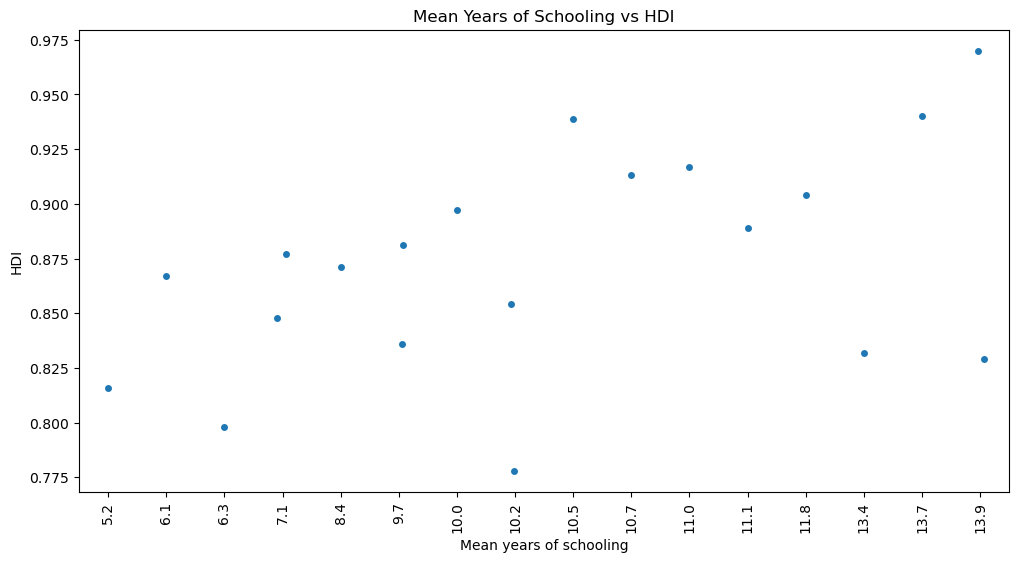

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.stripplot(
    x="Mean years of schooling",
    y="HDI",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.title("Mean Years of Schooling vs HDI")
plt.show()

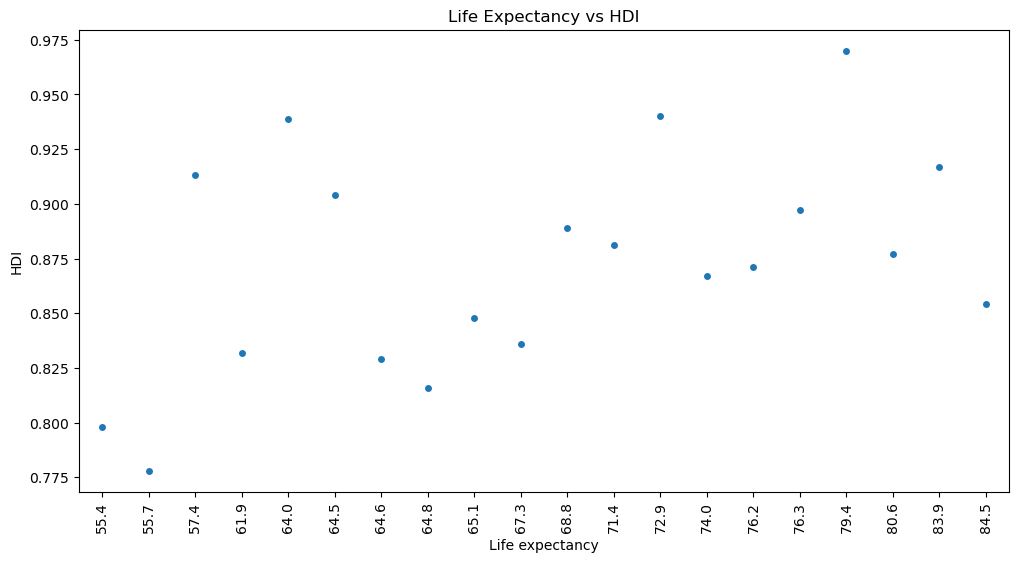

In [30]:
plt.figure(figsize=(12,6))

sns.stripplot(
    x="Life expectancy",
    y="HDI",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.title("Life Expectancy vs HDI")
plt.show()

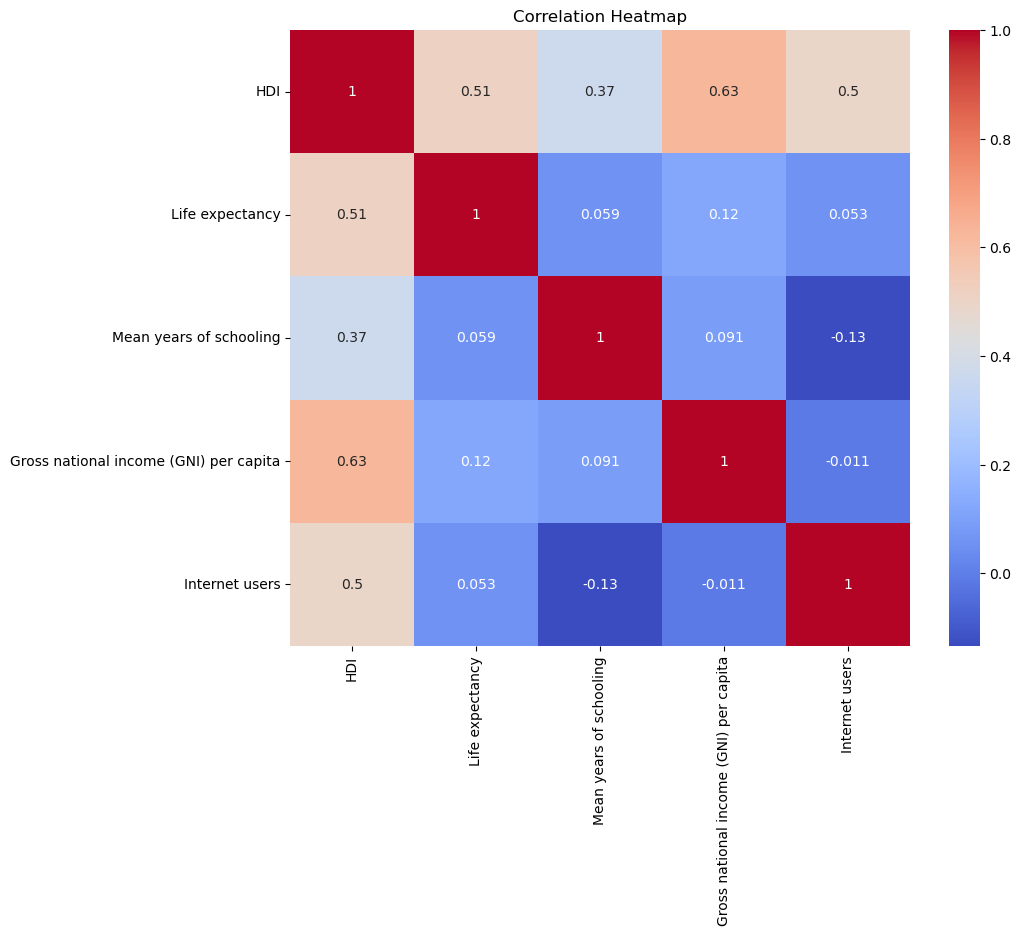

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    Development.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [32]:
X = Development[
    [
        "Life expectancy",
        "Mean years of schooling",
        "Gross national income (GNI) per capita",
        "Internet users"
    ]
]

y = Development["HDI"]

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(x_train.shape)
print(x_test.shape)

(152, 4)
(39, 4)


In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
prediction = model.predict(x_test)

prediction[:10]

array([0.72406, 0.81699, 0.87655, 0.82863, 0.77938, 0.77037, 0.77712,
       0.93378, 0.79061, 0.96663])

In [36]:
from sklearn.metrics import r2_score

score = r2_score(y_test, prediction)

print("R2 Score:", score)

R2 Score: 0.8405456961284912


In [38]:
import pickle

pickle.dump(model, open("../Flask/HDI.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
